/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/4221379449.py:11: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/4221379449.py:12: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


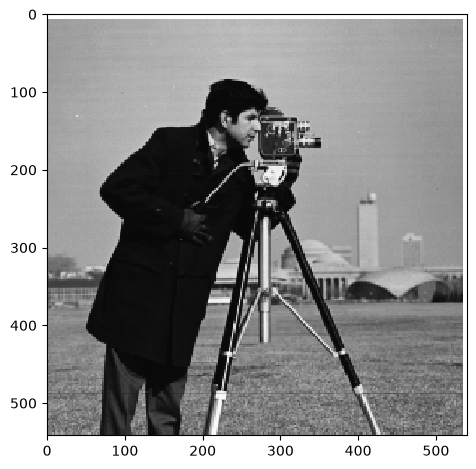

(542, 540)

In [2]:
import numpy as np
import skimage as sk
import skimage.io as skio

imname = 'images/cameraman.png'

im = skio.imread(imname)
im = sk.img_as_float(im)
im = sk.color.rgb2gray(im[:, :, :3])

skio.imshow(im)
skio.show()
im.shape

In [3]:
def convolution(img, kernel, padding=None):
    h, w = kernel.shape
    m, n = img.shape
    kernel = kernel[::-1,::-1]

    if padding == "same":
        # (m - h + 1) + 2 * pad = m -> 2 * pad = h - 1 -> odd kernel, pad = h // 2
        pad_h = h // 2
        pad_w = w // 2
    elif padding == "full":
        pad_h = h - 1
        pad_w = w - 1

    img_pad = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)))

    h_out = img_pad.shape[0] - h + 1
    w_out = img_pad.shape[1] - w + 1

    img_out = np.zeros(shape=(h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            val = 0
            for k in range(h):
                for l in range(w):
                    val += kernel[k][l] * img_pad[i+k][j+l]
            img_out[i][j] = val

    return img_out


/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/3257445501.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(imx)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/3257445501.py:7: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


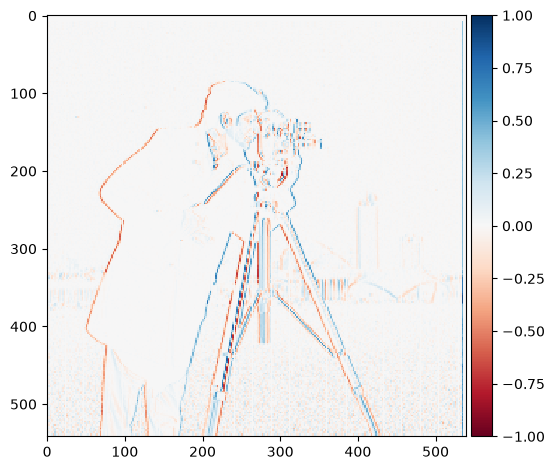

In [4]:
Dx = np.array([[1, 0, -1]])
Dy = np.array([[1], [0], [-1]])

imx = convolution(im, Dx, "same")

skio.imshow(imx)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/2203972350.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(imy)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/2203972350.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


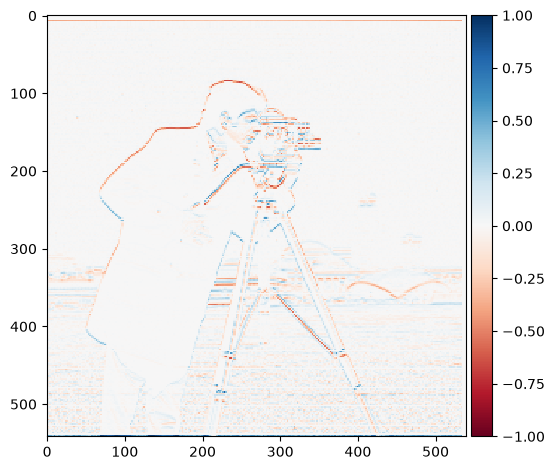

In [5]:
imy = convolution(im, Dy, "same")

skio.imshow(imy)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/1089194776.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(grad_mg)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/1089194776.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


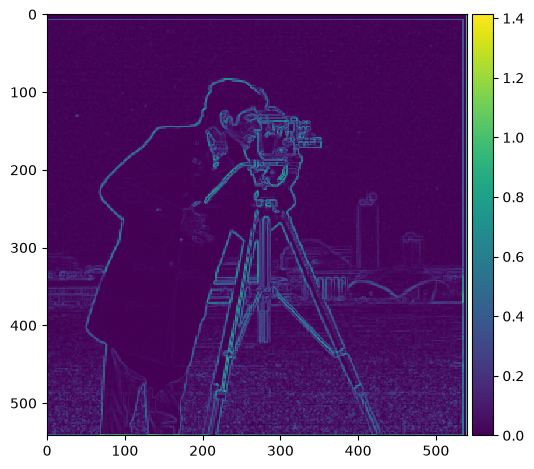

In [12]:
grad_mg = np.sqrt(imx ** 2 + imy ** 2)

skio.imshow(grad_mg)
skio.show()

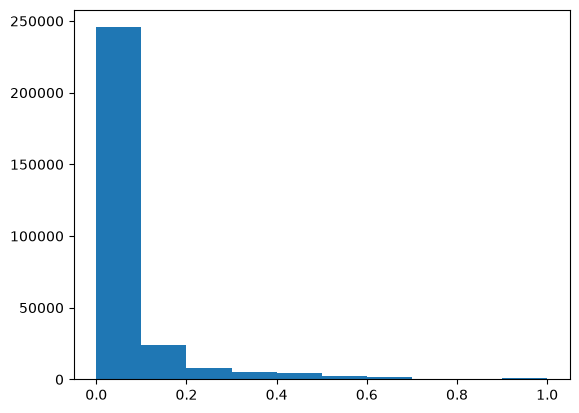

In [13]:
from matplotlib import pyplot as plt

plt.hist(grad_mg.flatten(), bins=10, range=(0, 1))
plt.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/4244434297.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_edge)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42697/4244434297.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


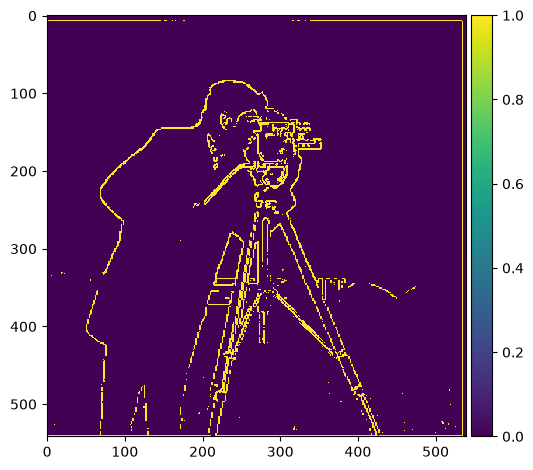

In [16]:
threshold = 0.3

im_edge = np.where(grad_mg > threshold, 1, 0)

skio.imshow(im_edge)
skio.show()